# Load Data

In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
file_path = '/content/drive/MyDrive/ColabData/MetroPT3(AirCompressor).csv'

df = pd.read_csv(
    file_path,
    parse_dates=['timestamp'],
    index_col='timestamp',
    thousands=',',
    decimal='.'
)

In [ ]:
# ==============================
# 2) Basic cleaning
# ==============================
df = df.copy()
df = df.sort_index()
df = df[~df.index.duplicated(keep="first")]

# Drop useless unnamed column if exists
for col in ["Unnamed: 0", "unnamed: 0", "index"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Keep numeric sensors only (RUL is regression on sensor signals)
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
df = df[numeric_cols].copy()

print("After basic cleaning:")
print("shape:", df.shape)
print("time range:", df.index.min(), "→", df.index.max())
print("num sensors:", len(df.columns))
df.head()

After basic cleaning:
shape: (1516948, 15)
time range: 2020-02-01 00:00:00 → 2020-09-01 03:59:50
num sensors: 15


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


# # Gap Handling (FINAL - robust)

In [ ]:
# Cell 6: Failure table
# ==============================
failures = pd.DataFrame({
    "nr": [1, 2, 3, 4],
    "failure": ["Air leak"]*4,
    "start": [
        "2020-04-18 00:00:00",
        "2020-05-29 23:30:00",
        "2020-06-05 10:00:00",
        "2020-07-15 14:30:00"
    ],
    "end": [
        "2020-04-18 23:59:00",
        "2020-05-30 06:00:00",
        "2020-06-07 14:30:00",
        "2020-07-15 19:00:00"
    ]
})
failures["start"] = pd.to_datetime(failures["start"])
failures["end"]   = pd.to_datetime(failures["end"])
failures = failures.sort_values("start").reset_index(drop=True)
failures


,nr,failure,start,end
0,1,Air leak,2020-04-18 00:00:00,2020-04-18 23:59:00
1,2,Air leak,2020-05-29 23:30:00,2020-05-30 06:00:00
2,3,Air leak,2020-06-05 10:00:00,2020-06-07 14:30:00
3,4,Air leak,2020-07-15 14:30:00,2020-07-15 19:00:00


In [ ]:
# Cell 5: Gap analysis + regularization
# ==============================
# Gap Handling (FINAL - robust)
# ==============================

EXPECTED = "10s"
SMALL_GAP_MAX = pd.Timedelta("120s")
SMALL_GAP_SAMPLES = int(SMALL_GAP_MAX / pd.Timedelta(EXPECTED))

ANALOG_COLS = ["TP2","TP3","H1","DV_pressure","Reservoirs","Oil_temperature","Motor_current"]
DIGITAL_COLS = ["COMP","DV_eletric","Towers","MPG","LPS","Pressure_switch","Oil_level","Caudal_impulses"]
FEATURE_COLS = ANALOG_COLS + DIGITAL_COLS

df = df.sort_index()
df = df[~df.index.duplicated(keep="first")]

# (1) SNAP timestamps to 10s grid to reduce jitter-loss
df2 = df.copy()
df2.index = df2.index.floor(EXPECTED)  # safer than round for time-series

agg = {c: "mean" for c in ANALOG_COLS}
agg.update({c: "max" for c in DIGITAL_COLS})

df2 = df2[FEATURE_COLS].groupby(level=0).agg(agg).sort_index()
df = df2

# (2) Regular 10s timeline once
df_rs = df.asfreq(EXPECTED)

# Identify missing rows (any sensor missing)
missing_any = df_rs[FEATURE_COLS].isna().any(axis=1)

# Group consecutive missing runs
grp = (missing_any != missing_any.shift()).cumsum()
miss_len = missing_any.groupby(grp).transform("sum")  # length of the run for each row
small_gap_rows = missing_any & (miss_len <= SMALL_GAP_SAMPLES)

df_filled = df_rs.copy()

# ---- Fill ANALOG small gaps: interpolate (limit) ----
df_filled[ANALOG_COLS] = df_filled[ANALOG_COLS].interpolate(
    method="time",
    limit=SMALL_GAP_SAMPLES,
    limit_direction="both"
)

# ---- Fill DIGITAL small gaps: ffill/bfill (limit) ----
# do it globally with limits
dig = df_filled[DIGITAL_COLS].copy()
dig = dig.ffill(limit=SMALL_GAP_SAMPLES).bfill(limit=SMALL_GAP_SAMPLES)

# keep values ONLY where gap is small OR original was not missing
keep_dig = (~missing_any) | small_gap_rows
dig.loc[~keep_dig, :] = np.nan

# enforce binary clean
for c in DIGITAL_COLS:
    dig[c] = dig[c].round().clip(0, 1)

df_filled[DIGITAL_COLS] = dig

# ---- Build segment_id based on BIG gaps on the grid ----
# "big gap" = missing run length > SMALL_GAP_SAMPLES
big_gap_rows = missing_any & (miss_len > SMALL_GAP_SAMPLES)
new_segment = big_gap_rows.shift(1, fill_value=True)  # start new segment after a big gap
df_filled["segment_id"] = new_segment.cumsum().astype(int)

# (3) Drop remaining NaNs (big gaps remain missing)
df_final = df_filled.dropna(subset=FEATURE_COLS).copy()

# (4) Rebuild failure labels after gap handling
df_final["failure"] = 0
for _, row in failures.iterrows():
    start = pd.to_datetime(row["start"])
    end   = pd.to_datetime(row["end"])
    df_final.loc[(df_final.index >= start) & (df_final.index < end), "failure"] = 1

print("\nAfter hybrid handling (FINAL):")
print("Rows:", len(df_final))
print("Segments:", df_final["segment_id"].nunique())
print("Time range:", df_final.index.min(), "->", df_final.index.max())
print("Remaining missing values:", int(df_final[FEATURE_COLS].isna().sum().sum()))


After hybrid handling (FINAL):
Rows: 1514745
Segments: 324
Time range: 2020-02-01 00:00:00 -> 2020-09-01 03:59:50
Remaining missing values: 0


In [ ]:
print("Data range:", df_final.index.min(), "->", df_final.index.max())
display(failures)

Data range: 2020-02-01 00:00:00 -> 2020-09-01 03:59:50


,nr,failure,start,end
0,1,Air leak,2020-04-18 00:00:00,2020-04-18 23:59:00
1,2,Air leak,2020-05-29 23:30:00,2020-05-30 06:00:00
2,3,Air leak,2020-06-05 10:00:00,2020-06-07 14:30:00
3,4,Air leak,2020-07-15 14:30:00,2020-07-15 19:00:00


In [ ]:
# ==========================================
# 1) Columns
# ==========================================
ANALOG_COLS = ["TP2","TP3","H1","DV_pressure","Reservoirs","Oil_temperature","Motor_current"]
DIGITAL_COLS = ["COMP","DV_eletric","Towers","MPG","LPS","Pressure_switch","Oil_level","Caudal_impulses"]
FEATURE_COLS = ANALOG_COLS + DIGITAL_COLS

# safety checks
missing_cols = [c for c in FEATURE_COLS + ["segment_id"] if c not in df_final.columns]
print("Missing columns:", missing_cols)

Missing columns: []


In [ ]:
# ==============================
# Cell C: Ensure failures datetime + align to 10s (recommended)
# ==============================
failures = failures.copy()
failures["start"] = pd.to_datetime(failures["start"]).dt.floor("10s")
failures["end"]   = pd.to_datetime(failures["end"]).dt.floor("10s")
failures = failures.sort_values("start").reset_index(drop=True)

print(failures)
print("Data range:", df_final.index.min(), "->", df_final.index.max())

   nr   failure               start                 end
0   1  Air leak 2020-04-18 00:00:00 2020-04-18 23:59:00
1   2  Air leak 2020-05-29 23:30:00 2020-05-30 06:00:00
2   3  Air leak 2020-06-05 10:00:00 2020-06-07 14:30:00
3   4  Air leak 2020-07-15 14:30:00 2020-07-15 19:00:00
Data range: 2020-02-01 00:00:00 -> 2020-09-01 03:59:50


# Build Runs + Compute RUL

In [ ]:
# ==========================================
# Build runs + Compute RUL (hours)
# ==========================================

import numpy as np
import pandas as pd

df2 = df_final.copy()

#  Remove downtime (failure intervals)
keep = pd.Series(True, index=df2.index)

for _, r in failures.iterrows():
    keep &= ~((df2.index >= r["start"]) & (df2.index < r["end"]))

df2 = df2.loc[keep].copy()

# 2 Initialize columns
df2["run_id"] = np.nan
df2["rul_hours"] = np.nan

# 3Assign runs and compute RUL
prev_end = df2.index.min()

for _, r in failures.iterrows():
    failure_start = r["start"]
    run_id = int(r["nr"])

    # this run is between previous failure end and current failure start
    mask = (df2.index > prev_end) & (df2.index <= failure_start)

    if mask.any():
        df2.loc[mask, "run_id"] = run_id
        df2.loc[mask, "rul_hours"] = (
            (failure_start - df2.index[mask]).total_seconds() / 3600.0
        )

    prev_end = r["end"]

# 4Drop rows outside run intervals
df2 = df2.dropna(subset=["run_id", "rul_hours"]).copy()
df2["run_id"] = df2["run_id"].astype(int)

print("Rows after run slicing:", len(df2))
print("Number of runs:", df2["run_id"].nunique())
print("Any negative RUL?", (df2["rul_hours"] < 0).any())

df2[["run_id", "rul_hours", "segment_id"]].head()

Rows after run slicing: 1142812
Number of runs: 4
Any negative RUL? False


,run_id,rul_hours,segment_id
timestamp,,,
2020-02-01 00:00:10,1,1847.997222,1
2020-02-01 00:00:20,1,1847.994444,1
2020-02-01 00:00:30,1,1847.991667,1
2020-02-01 00:00:40,1,1847.988889,1
2020-02-01 00:00:50,1,1847.986111,1


In [ ]:
# ==========================================
# Cap RUL to focus on degradation zone
# ==========================================

CAP_HOURS = 168  # 7 days

df2["rul_cap"] = df2["rul_hours"].clip(upper=CAP_HOURS)

print(df2[["rul_hours","rul_cap"]].describe())

          rul_hours       rul_cap
count  1.142812e+06  1.142812e+06
mean   6.835700e+02  1.535406e+02
std    4.897920e+02  3.822157e+01
min    2.777778e-03  2.777778e-03
25%    2.832333e+02  1.680000e+02
50%    6.047069e+02  1.680000e+02
75%    9.513917e+02  1.680000e+02
max    1.847997e+03  1.680000e+02


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Sanity check: how many runs (failures) do we have?
runs = sorted(df2["run_id"].unique())
print("Runs (failure cycles):", runs)
print("Samples per run:")
display(df2.groupby("run_id")["rul_cap"].agg(["count","min","max"]))


Runs (failure cycles): [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Samples per run:


,count,min,max
run_id,,,
1,558708,0.002778,168.000000
2,271174,0.002778,168.000000
3,47293,0.002778,147.997222
4,265637,0.002778,168.000000


In [ ]:
# ==============================
# Windowing WITH group ids (run_id)
# ==============================
SEQ_LEN = 180   # 30 minutes
STRIDE  = 10    # 100 seconds

def make_windows_with_groups(df_in, feature_cols, target_col, seq_len=180, stride=10):
    X_list, y_list, g_list = [], [], []
    for (rid, sid), g in df_in.groupby(["run_id","segment_id"]):
        g = g.sort_index()
        Xv = g[feature_cols].values
        yv = g[target_col].values
        n = len(g)
        if n < seq_len:
            continue
        for start in range(0, n - seq_len + 1, stride):
            end = start + seq_len
            X_list.append(Xv[start:end])
            y_list.append(yv[end-1])   # label at window end
            g_list.append(rid)         # group = run_id (failure cycle)
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), np.array(g_list, dtype=np.int32)

X_seq, y_all, groups = make_windows_with_groups(df2, FEATURE_COLS, "rul_cap", SEQ_LEN, STRIDE)

print("All windows:", X_seq.shape, "Targets:", y_all.shape)
print("Unique runs in windows:", np.unique(groups))


All windows: (110648, 180, 15) Targets: (110648,)
Unique runs in windows: [1 2 3 4]


In [ ]:
# ==============================
# Sequences -> Tabular features (for XGBoost / LightGBM)
# ==============================
def seq_to_tabular(X, feature_cols):
    mean   = X.mean(axis=1)
    std    = X.std(axis=1)
    mn     = X.min(axis=1)
    mx     = X.max(axis=1)
    rng    = mx - mn
    last   = X[:, -1, :]
    first  = X[:, 0, :]
    slope  = last - first
    dlast  = last - mean
    energy = (X**2).mean(axis=1)

    # digital transitions (0<->1)
    f2i = {c:i for i,c in enumerate(feature_cols)}
    digital_cols = ["COMP","DV_eletric","Towers","MPG","LPS",
                    "Pressure_switch","Oil_level","Caudal_impulses"]
    D = [f2i[c] for c in digital_cols if c in f2i]

    if len(D) > 0:
        Xd = X[:, :, D]
        trans = (np.abs(np.diff(Xd, axis=1)) > 0).sum(axis=1)  # (N, |D|)
    else:
        trans = np.zeros((X.shape[0], 0), dtype=np.float32)

    return np.concatenate([mean, std, mn, mx, rng, last, slope, dlast, energy, trans], axis=1).astype(np.float32)

X_tab = seq_to_tabular(X_seq, FEATURE_COLS)
print("Tabular features shape:", X_tab.shape)


Tabular features shape: (110648, 143)


In [ ]:
# ==============================
# Focus evaluation on degradation zone (optional but common in PdM papers)
# ==============================
DEG_THRESHOLD = 72.0  # hours

deg_mask = y_all <= DEG_THRESHOLD
X_seq_d = X_seq[deg_mask]
X_tab_d = X_tab[deg_mask]
y_d     = y_all[deg_mask]
g_d     = groups[deg_mask]

print("Degradation windows:", X_seq_d.shape, "Targets:", y_d.shape)
print("Per-run degradation windows:")
display(pd.DataFrame({"run_id": g_d}).value_counts().rename("n_windows").reset_index())


Degradation windows: (8475, 180, 15) Targets: (8475,)
Per-run degradation windows:


,run_id,n_windows
0,2,2373
1,1,2285
2,3,2097
3,4,1720


In [ ]:
# ==============================
# LOFO helpers
# ==============================
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def lofo_splits(group_ids):
    for test_run in sorted(np.unique(group_ids)):
        train_idx = group_ids != test_run
        test_idx  = group_ids == test_run
        yield test_run, train_idx, test_idx


In [ ]:
# ==============================
# LOFO - XGBoost (tabular)  ✅ fixed (callbacks)
## ==============================
# LOFO - XGBoost (tabular) ✅ ultra-compatible
# ==============================
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

xgb_params = dict(
    n_estimators=5000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,

    # ✅ put eval metric here (not in fit)
    eval_metric="rmse",
)

xgb_rows = []

for test_run, tr, te in lofo_splits(g_d):
    Xtr, ytr = X_tab_d[tr], y_d[tr]
    Xte, yte = X_tab_d[te], y_d[te]

    # scale (fit on train only)
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    model = xgb.XGBRegressor(**xgb_params)

    # ✅ No eval_metric / early_stopping_rounds / callbacks
    # (because your version rejects them)
    model.fit(Xtr_s, ytr)

    pred = model.predict(Xte_s)

    xgb_rows.append({
        "test_run": int(test_run),
        "n_test": int(len(yte)),
        "MAE_h": float(mean_absolute_error(yte, pred)),
        "RMSE_h": rmse(yte, pred),
    })

xgb_cv = pd.DataFrame(xgb_rows).sort_values("test_run")
display(xgb_cv)

print("XGBoost LOFO  MAE mean±std:", xgb_cv["MAE_h"].mean(), "±", xgb_cv["MAE_h"].std())
print("XGBoost LOFO RMSE mean±std:", xgb_cv["RMSE_h"].mean(), "±", xgb_cv["RMSE_h"].std())

,test_run,n_test,MAE_h,RMSE_h
0,1,2285,26.860966,31.573204
1,2,2373,26.543547,30.671808
2,3,2097,15.723064,19.610997
3,4,1720,17.579733,20.972193


XGBoost LOFO  MAE mean±std: 21.676827430725098 ± 5.853595012298168
XGBoost LOFO RMSE mean±std: 25.707050423565235 ± 6.288649046943743


In [ ]:
# ==============================
# LOFO - LightGBM (tabular) ✅ ultra-compatible
# ==============================
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

lgb_params = dict(
    objective="regression",
    n_estimators=4000,
    learning_rate=0.01,
    num_leaves=64,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

lgb_rows = []

for test_run, tr, te in lofo_splits(g_d):
    Xtr, ytr = X_tab_d[tr], y_d[tr]
    Xte, yte = X_tab_d[te], y_d[te]

    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    model = lgb.LGBMRegressor(**lgb_params)

    # ✅ no eval_set / no eval_metric / no callbacks
    model.fit(Xtr_s, ytr)

    pred = model.predict(Xte_s)

    lgb_rows.append({
        "test_run": int(test_run),
        "n_test": int(len(yte)),
        "MAE_h": float(mean_absolute_error(yte, pred)),
        "RMSE_h": rmse(yte, pred),
    })

lgb_cv = pd.DataFrame(lgb_rows).sort_values("test_run")
display(lgb_cv)

print("LightGBM LOFO  MAE mean±std:", lgb_cv["MAE_h"].mean(), "±", lgb_cv["MAE_h"].std())
print("LightGBM LOFO RMSE mean±std:", lgb_cv["RMSE_h"].mean(), "±", lgb_cv["RMSE_h"].std())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054878 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16273
[LightGBM] [Info] Number of data points in the train set: 6190, number of used features: 134
[LightGBM] [Info] Start training from score 34.146519


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010385 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16808
[LightGBM] [Info] Number of data points in the train set: 6102, number of used features: 138
[LightGBM] [Info] Start training from score 33.784393


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16971
[LightGBM] [Info] Number of data points in the train set: 6378, number of used features: 135
[LightGBM] [Info] Start training from score 36.095977


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16403
[LightGBM] [Info] Number of data points in the train set: 6755, number of used features: 135
[LightGBM] [Info] Start training from score 34.404267


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,test_run,n_test,MAE_h,RMSE_h
0,1,2285,27.185113,31.068319
1,2,2373,24.325004,28.175175
2,3,2097,16.705521,21.207276
3,4,1720,18.051009,20.655066


LightGBM LOFO  MAE mean±std: 21.56666161577105 ± 5.005528669418055
LightGBM LOFO RMSE mean±std: 25.276458777673366 ± 5.159577401921479


In [ ]:
# ==============================
# LOFO - 1D CNN (sequence model)
# Notes:
# - With only a few failure cycles, deep learning may overfit.
# - We still evaluate it fairly using LOFO and train-only scaling.
# ==============================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)
np.random.seed(42)

MAX_RUL = 72.0  # normalize targets to [0,1]

def residual_dilated_block(x, filters, kernel_size, dilation, dropout=0.2):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="same", dilation_rate=dilation)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv1D(filters, kernel_size, padding="same", dilation_rate=dilation)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def build_cnn(seq_len, n_feats):
    inp = layers.Input(shape=(seq_len, n_feats))
    x = layers.Conv1D(64, 3, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    for d in [1, 2, 4, 8]:
        x = residual_dilated_block(x, filters=64, kernel_size=3, dilation=d, dropout=0.2)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)  # normalized RUL in [0,1]
    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.Huber(delta=0.05),
        metrics=[]
    )
    return model

cnn_rows = []

for test_run, tr, te in lofo_splits(g_d):
    Xtr, ytr = X_seq_d[tr], y_d[tr]
    Xte, yte = X_seq_d[te], y_d[te]

    # scale features using train only (flatten time dimension)
    scaler = StandardScaler()
    Xtr2d = Xtr.reshape(-1, Xtr.shape[-1])
    Xte2d = Xte.reshape(-1, Xte.shape[-1])
    scaler.fit(Xtr2d)
    Xtr_s = scaler.transform(Xtr2d).reshape(Xtr.shape).astype("float32")
    Xte_s = scaler.transform(Xte2d).reshape(Xte.shape).astype("float32")

    # normalize targets + sample weights (focus near failure)
    ytr_n = (ytr / MAX_RUL).astype("float32")
    yte_n = (yte / MAX_RUL).astype("float32")
    wtr = (1.0 + 3.0 * (1.0 - ytr_n)).astype("float32")

    model = build_cnn(Xtr_s.shape[1], Xtr_s.shape[2])

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=4, factor=0.5, min_lr=1e-5)
    ]

    model.fit(
        Xtr_s, ytr_n,
        validation_data=(Xte_s, yte_n),
        sample_weight=wtr,
        epochs=50,
        batch_size=256,
        verbose=0,
        callbacks=cb
    )

    pred_n = model.predict(Xte_s, verbose=0).reshape(-1)
    pred_h = np.clip(pred_n * MAX_RUL, 0, MAX_RUL)

    cnn_rows.append({
        "test_run": int(test_run),
        "n_test": int(len(yte)),
        "MAE_h": float(mean_absolute_error(yte, pred_h)),
        "RMSE_h": rmse(yte, pred_h),
        "pred_min_h": float(pred_h.min()),
        "pred_max_h": float(pred_h.max())
    })

cnn_cv = pd.DataFrame(cnn_rows).sort_values("test_run")
display(cnn_cv)

print("1D CNN LOFO  MAE mean±std:", cnn_cv["MAE_h"].mean(), "±", cnn_cv["MAE_h"].std())
print("1D CNN LOFO RMSE mean±std:", cnn_cv["RMSE_h"].mean(), "±", cnn_cv["RMSE_h"].std())


,test_run,n_test,MAE_h,RMSE_h,pred_min_h,pred_max_h
0,1,2285,28.206131,34.041251,13.284352,63.738853
1,2,2373,24.370420,27.112863,28.144831,51.534985
2,3,2097,15.971455,18.883286,2.674724,71.601562
3,4,1720,20.133217,24.399915,34.728619,71.949318


1D CNN LOFO  MAE mean±std: 22.170305728912354 ± 5.2866869721818315
1D CNN LOFO RMSE mean±std: 26.109328739941834 ± 6.299742341440647


In [ ]:
# ==============================
# Final comparison table (LOFO mean ± std)
# ==============================
comparison_lofo = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "1D CNN"],
    "MAE_mean_h": [xgb_cv["MAE_h"].mean(), lgb_cv["MAE_h"].mean(), cnn_cv["MAE_h"].mean()],
    "MAE_std_h":  [xgb_cv["MAE_h"].std(),  lgb_cv["MAE_h"].std(),  cnn_cv["MAE_h"].std()],
    "RMSE_mean_h":[xgb_cv["RMSE_h"].mean(), lgb_cv["RMSE_h"].mean(), cnn_cv["RMSE_h"].mean()],
    "RMSE_std_h": [xgb_cv["RMSE_h"].std(),  lgb_cv["RMSE_h"].std(),  cnn_cv["RMSE_h"].std()],
})
display(comparison_lofo)


,Model,MAE_mean_h,MAE_std_h,RMSE_mean_h,RMSE_std_h
0,XGBoost,21.676827,5.853595,25.707050,6.288649
1,LightGBM,21.566662,5.005529,25.276459,5.159577
2,1D CNN,22.170306,5.286687,26.109329,6.299742


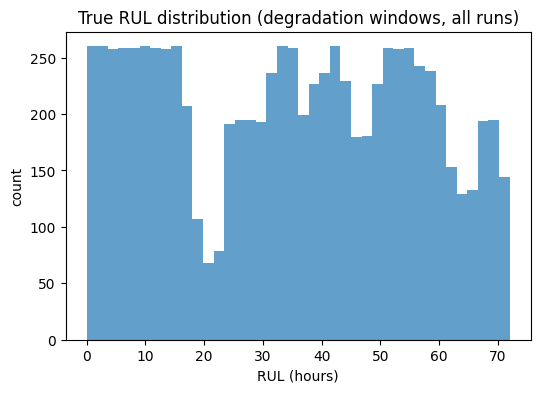

In [ ]:
# Optional: visualize fold predictions distribution (helps in papers)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(y_d, bins=40, alpha=0.7)
plt.title("True RUL distribution (degradation windows, all runs)")
plt.xlabel("RUL (hours)")
plt.ylabel("count")
plt.show()


In [ ]:
# ==============================
# SAVE — FINAL production RUL model (LightGBM) + scaler + feature cols + metadata
# ==============================
# The cells above are LOFO cross-VALIDATION only (each fold's model is discarded).
# Here we train ONE final production model on ALL degradation windows (all 4 runs).
#
# RUL branch contract (must be reproduced exactly at inference):
#   1) build windows from the RAW 15 channels (SEQ_LEN=180, STRIDE=10), segment/run aware
#      -> NOTE: RUL windows the RAW (unscaled) channels, unlike IF/LSTM
#   2) seq_to_tabular  -> 143 engineered features
#   3) StandardScaler (fit on the 143 features)  -> scale   [scaler is AFTER engineering]
#   4) LightGBM.predict -> clip to [0, 72]
#   5) map hours -> zone: NOMINAL >48h / DEGRADATION 12-48h / CRITICAL <12h
#
# DECISION: trained on degradation zone (RUL <= 72h) to match the validated MAE ~21.6h.
#   => On a HEALTHY machine this model is NOT meaningful. The backend must gate RUL
#      behind the anomaly detector: only show a number once degradation/anomaly is
#      detected; otherwise display "NOMINAL".
import joblib, json, os
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/SmartMetro_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 1) build the 143 feature names matching seq_to_tabular() layout ---
# seq_to_tabular concatenates: [mean, std, min, max, range, last, slope, dlast, energy] x FEATURE_COLS (15 each)
# then [trans] x DIGITAL_COLS (8). Total = 15*9 + 8 = 143.
_stat_blocks = ["mean", "std", "min", "max", "range", "last", "slope", "dlast", "energy"]
rul_feature_cols = []
for stat in _stat_blocks:
    rul_feature_cols += [f"{c}_{stat}" for c in FEATURE_COLS]
rul_feature_cols += [f"{c}_trans" for c in DIGITAL_COLS]
assert len(rul_feature_cols) == X_tab_d.shape[1], (len(rul_feature_cols), X_tab_d.shape[1])

# --- 2) fit production scaler on ALL degradation windows (143 features) ---
rul_scaler = StandardScaler()
X_tab_d_s = rul_scaler.fit_transform(X_tab_d)

# --- 3) train final LightGBM on ALL degradation windows (same params as the LOFO winner) ---
rul_model = lgb.LGBMRegressor(**lgb_params)
rul_model.fit(X_tab_d_s, y_d)
print(f"✅ Final RUL LightGBM trained on {X_tab_d_s.shape[0]} degradation windows, {X_tab_d_s.shape[1]} features")

# --- 4) save artifacts ---
joblib.dump(rul_model, f"{SAVE_DIR}/rul_lgbm.pkl")
joblib.dump(rul_scaler, f"{SAVE_DIR}/rul_scaler_sd.pkl")
joblib.dump(rul_feature_cols, f"{SAVE_DIR}/rul_feature_cols.pkl")
print("✅ Saved -> rul_lgbm.pkl, rul_scaler_sd.pkl, rul_feature_cols.pkl")

# --- 5) metadata (full reproduction + deployment contract) ---
rul_metadata = {
    "model_file": "rul_lgbm.pkl",
    "scaler_file": "rul_scaler_sd.pkl",
    "feature_cols_file": "rul_feature_cols.pkl",
    "algorithm": "LightGBM",
    "lgb_params": {k: (v if isinstance(v, (int, float, str, bool, type(None))) else str(v))
                   for k, v in lgb_params.items()},
    "raw_channel_order": list(FEATURE_COLS),       # 15 channels, order used for windowing
    "analog_cols": list(ANALOG_COLS),
    "digital_cols": list(DIGITAL_COLS),
    "windows_raw_channels": True,                  # RUL windows RAW channels (no pre-scaling), unlike IF/LSTM
    "scaler_applies_to": "engineered_143_features_after_windowing",
    "seq_len": int(SEQ_LEN),                       # 180  (30 min)
    "stride": int(STRIDE),                         # 10
    "n_features": int(X_tab_d.shape[1]),           # 143
    "feature_layout": {
        "blocks": _stat_blocks,                    # each block = 15 cols in raw_channel_order
        "then": "trans per digital_col (8)",
    },
    "trained_on": "degradation_zone_RUL_le_72h",
    "deg_threshold_h": 72.0,
    "cap_hours": 168.0,
    "predict_clip_h": [0.0, 72.0],
    "display_zones_h": {"NOMINAL": ">48", "DEGRADATION": "12-48", "CRITICAL": "<12"},
    "deployment_note": "Model is only meaningful during degradation. Backend MUST gate RUL "
                       "behind anomaly detection; show 'NOMINAL' when no anomaly.",
    # validated performance (LOFO means from cell 20 / cell 22)
    "validated_mae_h": float(lgb_cv["MAE_h"].mean()),
    "validated_mae_std_h": float(lgb_cv["MAE_h"].std()),
    "validated_rmse_h": float(lgb_cv["RMSE_h"].mean()),
    "validated_rmse_std_h": float(lgb_cv["RMSE_h"].std()),
    "validation_method": "Leave-One-Failure-Out (4 runs)",
}

with open(f"{SAVE_DIR}/rul_metadata.json", "w") as f:
    json.dump(rul_metadata, f, indent=2)
print("✅ RUL metadata saved -> rul_metadata.json")
print(json.dumps(rul_metadata, indent=2))
